In [1]:
import sys

# Necessary to import from src dir
sys.path.append('../..')

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import re
import seaborn as sns

from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix
)

from src.logistic_regression import (
    model_predict_binary,
    plot_sigmoid,
    run_lasso_logistic_regression
)
from src.preprocessing import prepare_standardized_datasets

In [3]:
DATA_DIR = r"./../data/"
OUTPUT_DIR = r"./../outputs/"

TRAIN_DATA = os.path.join(DATA_DIR, "train.csv")
TEST_DATA = os.path.join(DATA_DIR, "test.csv")

# Preprocessing

df_train = pd.read_csv(TRAIN_DATA)
df_test = pd.read_csv(TEST_DATA)

label_var = "class4"

# Include only the real-valued mean values, but don't exclude anything further than that yet before exploring the data a bit first
cols_to_include = [feat for feat in df_train.columns.to_list() if (feat.endswith(".mean")) or (feat == label_var)]

numeric_vars = cols_to_include[:]
numeric_vars.remove(label_var)

df_train_standardized, df_validation_standardized, df_test_standardized = prepare_standardized_datasets(
    df_train=df_train,
    df_test=df_test,
    data_vars=numeric_vars,
    label_var=label_var,
    label_values=("nonevent", "event"),
    include_validation_split=True,
    validation_split_size=0.2
)

df_train_standardized.head()

,class4,class2,CO2168.mean,CO2336.mean,CO242.mean,CO2504.mean,Glob.mean,H2O168.mean,H2O336.mean,H2O42.mean,...,SO2168.mean,SWS.mean,T168.mean,T42.mean,T504.mean,T672.mean,T84.mean,UV_A.mean,UV_B.mean,CS.mean
0,II,event,-0.517164,-0.522329,-0.602727,-0.514968,-1.378833,-1.339408,-1.344634,-1.327464,...,1.613413,0.390262,-1.685854,-1.687896,-1.694506,-1.707449,-1.689979,-1.430610,-1.307957,-1.186655
1,Ib,event,-0.222318,-0.223990,-0.290753,-0.218241,0.165179,-0.497053,-0.494458,-0.500215,...,-0.526001,0.143059,-0.411603,-0.402712,-0.432206,-0.439512,-0.406468,0.283483,-0.182347,-1.016162
2,Ib,event,0.313043,0.312527,0.257770,0.321229,0.055473,-1.109986,-1.112464,-1.106024,...,3.319529,0.494921,-1.373718,-1.363220,-1.400586,-1.419243,-1.364413,0.015756,-0.392941,0.866100
3,nonevent,nonevent,0.995457,0.997079,0.929490,1.004675,-1.360423,0.137916,0.145219,0.163682,...,-0.533453,-1.706845,-0.182597,-0.188675,-0.180631,-0.182470,-0.193358,-1.394971,-1.272186,-0.931761
4,nonevent,nonevent,-1.972206,-2.036199,-1.914174,-2.129910,0.558218,2.488027,2.501735,2.468074,...,0.696809,0.645170,1.478209,1.505584,1.505153,1.504820,1.487600,0.767687,0.777764,1.878317


In [14]:
cols_to_include_extended = [feat for feat in df_train.columns.to_list() if (feat.endswith(".mean")) or (feat.endswith(".std")) or (feat == label_var)]
numeric_vars_extended = cols_to_include_extended[:]
numeric_vars_extended.remove(label_var)

In [4]:
def run_binary_logistic_regression_with_lasso(
    ax,
    training_data,
    test_data,
    target_label="nonevent",
    inverse_label="event"
):
    X_train = training_data[numeric_vars]
    y_train = training_data["class2"]
    X_test = test_data[numeric_vars]
    y_test = test_data["class2"]

    lasso = run_lasso_logistic_regression(X_train, y_train)

    train_accuracy, test_accuracy = model_predict_binary(
        model=lasso,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        target_label=target_label
    )
    
    print(f"LASSO train accuracy: {train_accuracy}")
    print(f"LASSO test accuracy: {test_accuracy}")

    plot_sigmoid(
        ax=ax,
        model=lasso,
        X_train=X_train,
        y_train=y_train,
        target_label=target_label,
        inverse_label=inverse_label
    )

LASSO train accuracy: 0.9
LASSO test accuracy: 0.8


Text(0.5, 0.98, 'Class2 Classification with all mean values')

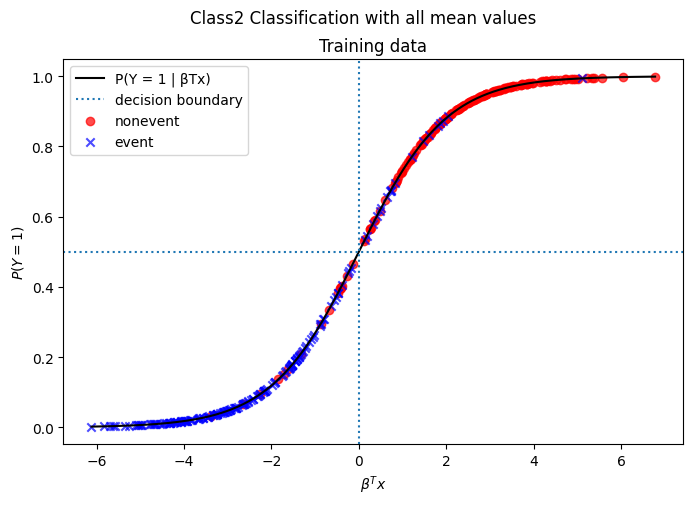

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
run_binary_logistic_regression_with_lasso(
    ax,
    df_train_standardized,
    df_validation_standardized,
    target_label="nonevent",
    inverse_label="event"
)
fig.suptitle("Class2 Classification with all mean values")

LASSO train accuracy: 0.9055555555555556
LASSO test accuracy: 0.8111111111111111


Text(0.5, 0.98, 'Class2 Classification with all mean & std values')

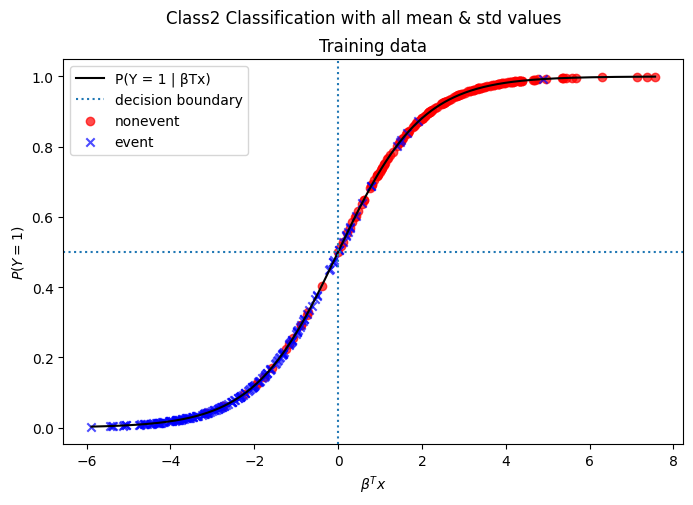

In [16]:
df_train_standardized_full, df_validation_standardized_full, _ = prepare_standardized_datasets(
    df_train=df_train,
    df_test=df_test,
    data_vars=numeric_vars_extended,
    label_var=label_var,
    label_values=("nonevent", "event"),
    include_validation_split=True,
    validation_split_size=0.2
)

fig, ax = plt.subplots(figsize=(8, 5))
run_binary_logistic_regression_with_lasso(
    ax,
    df_train_standardized_full,
    df_validation_standardized_full,
    target_label="nonevent",
    inverse_label="event"
)
fig.suptitle("Class2 Classification with all mean & std values")

### Drop event type II

Repeat the same process with reduced data. Because event type II has questionable accuracy, just use event type I in the binary classification (event vs. nonevent).

In [6]:
# Drop event type II events

df_train_reduced = df_train_standardized.drop(df_train_standardized[df_train_standardized["class4"] == "II"].index)
df_validation_reduced = df_validation_standardized.drop(df_validation_standardized[df_validation_standardized["class4"] == "II"].index)

LASSO train accuracy: 0.9277566539923955
LASSO test accuracy: 0.8428571428571429


Text(0.5, 0.98, 'Class2 classification with event types I vs. nonevents')

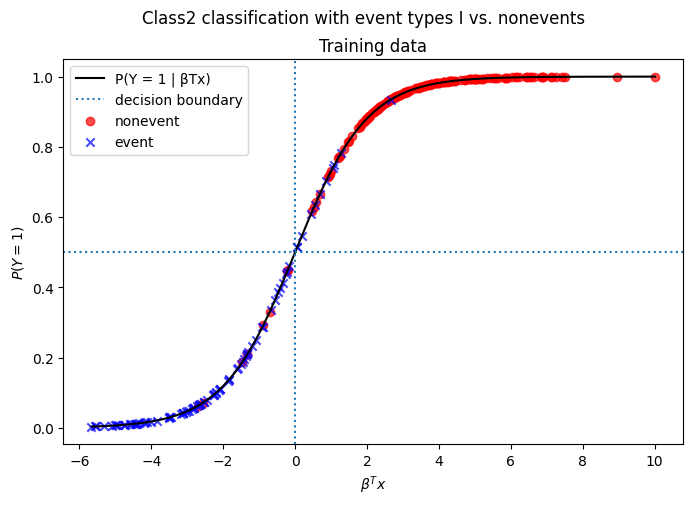

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
run_binary_logistic_regression_with_lasso(
    ax,
    df_train_reduced,
    df_validation_reduced,
    target_label="nonevent",
    inverse_label="event"
)
fig.suptitle("Class2 classification with event types I vs. nonevents")

### Drop event type II + oversample event types Ia and Ib

In [12]:
ros = RandomOverSampler(random_state=0)
X_train_ros, y_train_ros = ros.fit_resample(df_train_reduced[numeric_vars], df_train_reduced["class2"])
df_X_ros = pd.DataFrame(X_train_ros, columns=numeric_vars)
df_X_ros["class2"] = y_train_ros

LASSO train accuracy: 0.9485714285714286
LASSO test accuracy: 0.8142857142857143


Text(0.5, 0.98, 'Class2 classification with event types I vs. nonevents and oversampling')

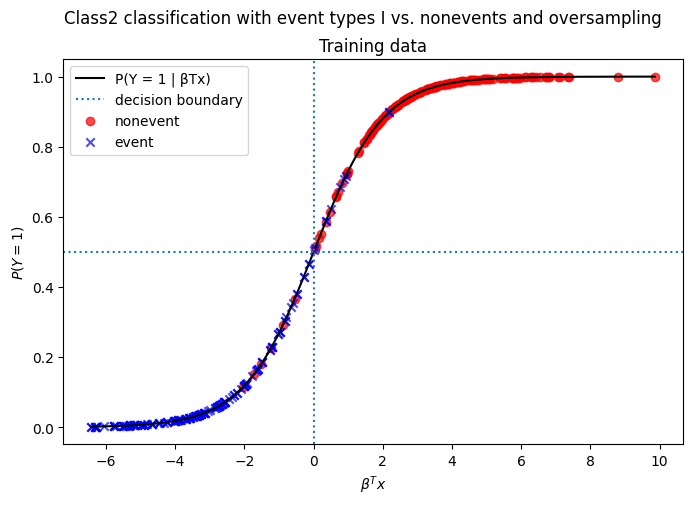

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
run_binary_logistic_regression_with_lasso(
    ax,
    df_X_ros,
    df_validation_reduced,
    target_label="nonevent",
    inverse_label="event"
)
fig.suptitle("Class2 classification with event types I vs. nonevents and oversampling")

### Combine redundant data columns

In [19]:
def combine_columns(
    df_train,
    patterns
):
    for col, pattern in patterns.items():
        cols_to_combine = []
        for feat in df_train.columns.to_list():
            matches = re.findall(pattern, feat)
            if len(matches) > 0:
                cols_to_combine = cols_to_combine + matches
    
        if len(cols_to_combine) > 1:
            df_train[col] = df_train[cols_to_combine].mean(axis=1)
    
            df_train = df_train.drop(columns=cols_to_combine)

    return df_train

In [20]:
patterns = {
    "CO2_combined.mean": rf"CO2\d{{2,3}}.mean",
    "H2O_combined.mean": rf"H2O\d{{2,3}}.mean",
    "NO_combined.mean": rf"NO\d{{2,3}}.mean",
    "NOx_combined.mean": rf"NOx\d{{2,3}}.mean",
    "O3_combined.mean": rf"O3\d{{2,3}}.mean",
    "RHIRGA_combined.mean": rf"RHIRGA\d{{2,3}}.mean",
    "T_combined.mean": rf"T\d{{2,3}}.mean"
}

df_train_combine = combine_columns(df_train, patterns)

LASSO train accuracy: 0.8632478632478633
LASSO test accuracy: 0.9


Text(0.5, 0.98, 'Class2 Classification combined mean & std values')

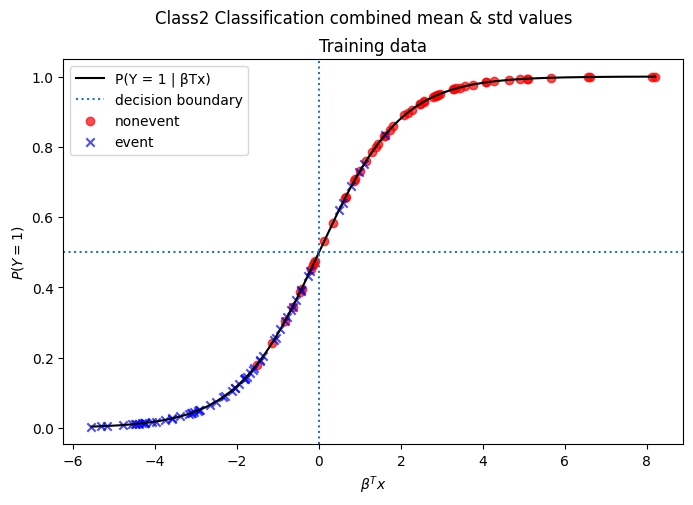

In [27]:
df_train, df_validation, _ = prepare_standardized_datasets(
    df_train=df_train,
    df_test=df_test,
    data_vars=numeric_vars,
    label_var=label_var,
    label_values=("nonevent", "event"),
    include_validation_split=True,
    validation_split_size=0.2
)

fig, ax = plt.subplots(figsize=(8, 5))
run_binary_logistic_regression_with_lasso(
    ax,
    df_train,
    df_validation,
    target_label="nonevent",
    inverse_label="event"
)
fig.suptitle("Class2 Classification combined mean & std values")